# Problem 1
Encoder-Decoder vs. Decoder-Only: The original Transformer (Vaswani et al. 2017) uses an encoder-decoder
structure. However, for forecasting, sometimes a decoder-only (auto-regressive) transformer is used. Briefly
discuss the difference and why a decoder-only Transformer can be sufficient for time series forecasting.

In [1]:
from pathlib import Path
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device {DEVICE}")

device cpu


## A.
Data Preparation: Load the weather time series dataset (see previous exercise). This is likely a
multivariate time series (e.g., temperature, pressure, humidity, etc.).

Raw data: 26,496 rows, 30 variables
Daily data: 185 days, 30 variables
Date range: 2021-07-01 to 2022-01-01
Forecasting setup: past 30 days -> next 7 days of T (degC)
All windows: X=(149, 30, 30), y=(149, 7)
Train/val/test windows: 93 / 22 / 22


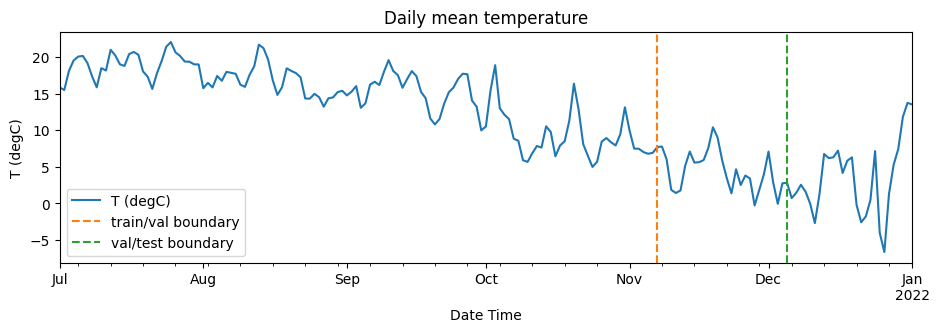

In [2]:
TARGET = "T (degC)"
LOOKBACK = 30
HORIZON = 7
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
BATCH_SIZE = 32


CSV_PATH = Path("mpi_saale_2021b.csv")
weather_raw = pd.read_csv(CSV_PATH, sep=",", skipinitialspace=True)
weather_raw.columns = [c.strip().strip('"') for c in weather_raw.columns]
weather_raw["Date Time"] = pd.to_datetime(weather_raw["Date Time"], format="%d.%m.%Y %H:%M:%S")
weather_raw = weather_raw.set_index("Date Time").sort_index()
weather_raw = weather_raw.apply(pd.to_numeric, errors="coerce")

weather_daily = (
    weather_raw.resample("1D")
    .mean(numeric_only=True)
    .interpolate(limit_direction="both")
    .dropna(axis=1, how="any")
)

feature_columns = weather_daily.columns.tolist()
target_index = feature_columns.index(TARGET)

train_end = int(len(weather_daily) * TRAIN_SPLIT)
val_end = int(len(weather_daily) * (TRAIN_SPLIT + VAL_SPLIT))

feature_scaler = StandardScaler().fit(weather_daily.iloc[:train_end])
target_scaler = StandardScaler().fit(weather_daily.iloc[:train_end][[TARGET]])
scaled_values = feature_scaler.transform(weather_daily).astype(np.float32)


def make_windows(values, dates, lookback, horizon, target_col):
    X, y, x_dates, y_dates = [], [], [], []
    for start in range(len(values) - lookback - horizon + 1):
        hist_end = start + lookback
        forecast_end = hist_end + horizon
        X.append(values[start:hist_end])
        y.append(values[hist_end:forecast_end, target_col])
        x_dates.append(dates[start:hist_end])
        y_dates.append(dates[hist_end:forecast_end])
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(x_dates),
        np.asarray(y_dates),
    )


X, y, history_dates, forecast_dates = make_windows(
    scaled_values, weather_daily.index, LOOKBACK, HORIZON, target_index
)

train_boundary = weather_daily.index[train_end]
val_boundary = weather_daily.index[val_end]
train_mask = forecast_dates[:, -1] < train_boundary
val_mask = (forecast_dates[:, 0] >= train_boundary) & (forecast_dates[:, -1] < val_boundary)
test_mask = forecast_dates[:, 0] >= val_boundary

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
history_dates_test = history_dates[test_mask]
forecast_dates_test = forecast_dates[test_mask]


print(f"Raw data: {weather_raw.shape[0]:,} rows, {weather_raw.shape[1]} variables")
print(f"Daily data: {weather_daily.shape[0]} days, {weather_daily.shape[1]} variables")
print(f"Date range: {weather_daily.index.min().date()} to {weather_daily.index.max().date()}")
print(f"Forecasting setup: past {LOOKBACK} days -> next {HORIZON} days of {TARGET}")
print(f"All windows: X={X.shape}, y={y.shape}")
print(f"Train/val/test windows: {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}")

fig, ax = plt.subplots(figsize=(11, 3))
weather_daily[TARGET].plot(ax=ax, color="tab:blue")
ax.axvline(train_boundary, color="tab:orange", linestyle="--", label="train/val boundary")
ax.axvline(val_boundary, color="tab:green", linestyle="--", label="val/test boundary")
ax.set_title("Daily mean temperature")
ax.set_ylabel(TARGET)
ax.legend()
plt.show()

In [3]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=BATCH_SIZE,
)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def regression_metrics(y_true, y_pred):
    return {
        "MAE (degC)": float(np.mean(np.abs(y_true - y_pred))),
        "RMSE (degC)": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
    }

## B. 
Transformer Model Implementation: Construct a transformer-based model for time series forecast-
ing. You have flexibility in design: One approach is to use an encoder-decoder structure: the encoder
processes the past 30 days of multivariate data, and the decoder generates the next 7 days of the target
(with appropriate masking so that at training time the decoder can attend to previous target values).
Alternatively, implement a decoder-only transformer that takes the 30-day history as context and autore-
gressively predicts each step up to 7 days (feeding back predictions, using masked self-attention to prevent
seeing future data). Use library components where possible (e.g., torch.nn.Transformer or Keras MultiHea-
dAttention layers) rather than coding attention from scratch. Include positional encoding in your model.
For instance, in PyTorch you can use nn.Transformer which includes embedding + positional encoding, or
manually add sinusoidal positional features to inputs

In [4]:
class TransformerForecaster(nn.Module):
    def __init__(
        self,
        n_features,
        target_col,
        lookback,
        horizon,
        d_model=64,
        n_heads=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
    ):
        super().__init__()
        self.target_col = target_col
        self.lookback = lookback
        self.horizon = horizon
        self.src_embedding = nn.Linear(n_features, d_model)
        self.tgt_embedding = nn.Linear(1, d_model)
        self.src_position = nn.Embedding(lookback, d_model)
        self.tgt_position = nn.Embedding(horizon, d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(d_model, 1)

    def forward(self, x, y=None):
        src_pos = torch.arange(self.lookback, device=x.device)
        tgt_pos = torch.arange(self.horizon, device=x.device)
        src = self.src_embedding(x) + self.src_position(src_pos).unsqueeze(0)
        src = self.dropout(src)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(self.horizon, device=x.device)

        # if y is provided, force true predictions
        if y is not None:
            decoder_input = torch.zeros_like(y)
            decoder_input[:, 0] = x[:, -1, self.target_col]     # start with last known value
            decoder_input[:, 1:] = y[:, :-1]        # force true predictions
            tgt = self.tgt_embedding(decoder_input.unsqueeze(-1)) + self.tgt_position(tgt_pos).unsqueeze(0)
            out = self.transformer(src, self.dropout(tgt), tgt_mask=tgt_mask)
            return self.output(out).squeeze(-1)

        decoder_input = torch.zeros(x.size(0), self.horizon, device=x.device, dtype=x.dtype)
        decoder_input[:, 0] = x[:, -1, self.target_col]
        predictions = []
        for step in range(self.horizon):
            tgt = self.tgt_embedding(decoder_input.unsqueeze(-1)) + self.tgt_position(tgt_pos).unsqueeze(0)
            out = self.transformer(src, self.dropout(tgt), tgt_mask=tgt_mask)
            step_prediction = self.output(out[:, step]).squeeze(-1)
            predictions.append(step_prediction)
            if step + 1 < self.horizon:
                decoder_input[:, step + 1] = step_prediction
        return torch.stack(predictions, dim=1)

## D. 

STM Benchmark Model: Using your knowledge from previous list 1, set up a sequence-to-sequence
LSTM model for the same task.

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        n_features,
        target_col,
        horizon,
        hidden_size=64,
        num_layers=2,
        dropout=0.15,
    ):
        super().__init__()
        self.target_col = target_col
        self.horizon = horizon
        self.encoder = nn.LSTM(
            n_features,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder_cell = nn.LSTMCell(1, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x, y=None):
        _, (hidden, cell) = self.encoder(x)
        decoder_hidden = hidden[-1]
        decoder_cell = cell[-1]
        decoder_input = x[:, -1, self.target_col : self.target_col + 1]
        outputs = []
        for step in range(self.horizon):
            decoder_hidden, decoder_cell = self.decoder_cell(decoder_input, (decoder_hidden, decoder_cell))
            step_output = self.output(self.dropout(decoder_hidden))
            outputs.append(step_output)
            decoder_input = y[:, step : step + 1] if y is not None else step_output
        return torch.cat(outputs, dim=1)

## C.
Training: Train the Transformer model on the training set. Because transformers have many pa-
rameters, use techniques to aid learning: e.g., a relatively large batch size (if data allows), learning rate
scheduling, and possibly more epochs. Monitor validation loss for hyperparameter tuning. Training might
be slower than RNNs, so be mindful of training time.

In [6]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=120,
    lr=2e-3,
    weight_decay=1e-4,
    patience=18,
    clip_grad=1.0,
):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(3, patience // 4)
    )

    history = []
    best_val_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred = model(batch_x, batch_y)
            loss = criterion(pred, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(DEVICE)
                batch_y = batch_y.to(DEVICE)
                pred = model(batch_x)
                val_losses.append(criterion(pred, batch_y).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch, "loss": train_loss, "val_loss": val_loss, "lr": current_lr})

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    elapsed = time.perf_counter() - start_time
    if best_state is not None:
        model.load_state_dict(best_state)
    return pd.DataFrame(history), elapsed, best_val_loss

In [7]:
def make_transformer(n_heads=4, num_layers=2, d_model=64):
    return TransformerForecaster(
        n_features=X_train.shape[2],
        target_col=target_index,
        lookback=LOOKBACK,
        horizon=HORIZON,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        dim_feedforward=2 * d_model,
        dropout=0.10,
    )


lstm_model = LSTMForecaster(
    n_features=X_train.shape[2],
    target_col=target_index,
    horizon=HORIZON,
    hidden_size=64,
    num_layers=2,
    dropout=0.15,
)
transformer_4h = make_transformer(n_heads=4, num_layers=2, d_model=64)
transformer_8h = make_transformer(n_heads=8, num_layers=2, d_model=64)

experiments = {
    "LSTM": lstm_model,
    "Transformer 4 heads": transformer_4h,
    "Transformer 8 heads": transformer_8h,
}

training_histories = {}
training_rows = []

for name, model in experiments.items():
    print(f"Training {name} ({count_parameters(model):,} parameters)")
    history, train_time, best_val = train_model(model, train_loader, val_loader)
    training_histories[name] = history
    training_rows.append(
        {
            "model": name,
            "parameters": count_parameters(model),
            "epochs_run": int(history["epoch"].iloc[-1]),
            "best_val_MSE_scaled": best_val,
            "training_time_s": train_time,
        }
    )

training_summary = pd.DataFrame(training_rows).sort_values("best_val_MSE_scaled")
training_summary

Training LSTM (75,073 parameters)


Training Transformer 4 heads (172,225 parameters)


Training Transformer 8 heads (172,225 parameters)


,model,parameters,epochs_run,best_val_MSE_scaled,training_time_s
2,Transformer 8 heads,172225,19,0.370445,3.378920
1,Transformer 4 heads,172225,20,0.565279,2.808344
0,LSTM,75073,23,0.621609,1.175820


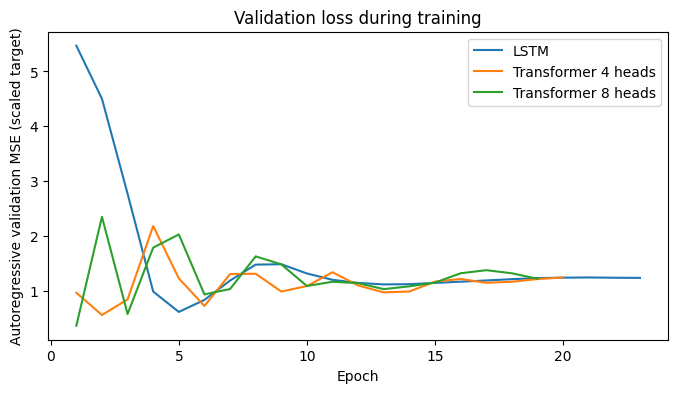

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, history in training_histories.items():
    ax.plot(history["epoch"], history["val_loss"], label=name)
ax.set_title("Validation loss during training")
ax.set_xlabel("Epoch")
ax.set_ylabel("Autoregressive validation MSE (scaled target)")
ax.legend()
plt.show()

## E.
Evaluation – Forecast Accuracy: Evaluate both models (Transformer and LSTM) on the test set
by producing 7-day forecasts for each window and comparing to actual values. Use metrics suitable for
multi-step forecasts, e.g., Mean Absolute Error and RMSE for each horizon step and/or overall (you can
compute an average MAE over all forecasted points, and also check MAE at day +1, +3, +7 separately to
see if error grows). If the dataset is multivariate and you used additional features, make sure to also feed
the necessary exogenous features to the models at prediction time (if required by your model design).

In [9]:
def predict_scaled(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(DEVICE)
            preds.append(model(batch_x).cpu().numpy())
    return np.vstack(preds)


y_test_c = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
metric_rows = []
horizon_rows = []
predictions_c = {}

for name, model in experiments.items():
    pred_scaled = predict_scaled(model, test_loader)
    pred_c = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(pred_scaled.shape)
    predictions_c[name] = pred_c
    row = {"model": name, **regression_metrics(y_test_c, pred_c)}
    metric_rows.append(row)
    for horizon_idx in [0, 2, 6]:
        step_true = y_test_c[:, horizon_idx]
        step_pred = pred_c[:, horizon_idx]
        horizon_rows.append(
            {
                "model": name,
                "horizon": f"+{horizon_idx + 1} day",
                **regression_metrics(step_true, step_pred),
            }
        )

accuracy_summary = pd.DataFrame(metric_rows).sort_values("MAE (degC)")
horizon_summary = pd.DataFrame(horizon_rows)
accuracy_summary

,model,MAE (degC),RMSE (degC)
2,Transformer 8 heads,3.986046,4.805913
1,Transformer 4 heads,4.549549,5.911503
0,LSTM,4.739524,6.136115


In [10]:
horizon_summary.pivot(index="horizon", columns="model", values="MAE (degC)").loc[["+1 day", "+3 day", "+7 day"]]

model,LSTM,Transformer 4 heads,Transformer 8 heads
horizon,,,
+1 day,5.158890,4.775101,3.732752
+3 day,4.645161,4.782928,3.747303
+7 day,4.743519,4.495285,4.531784


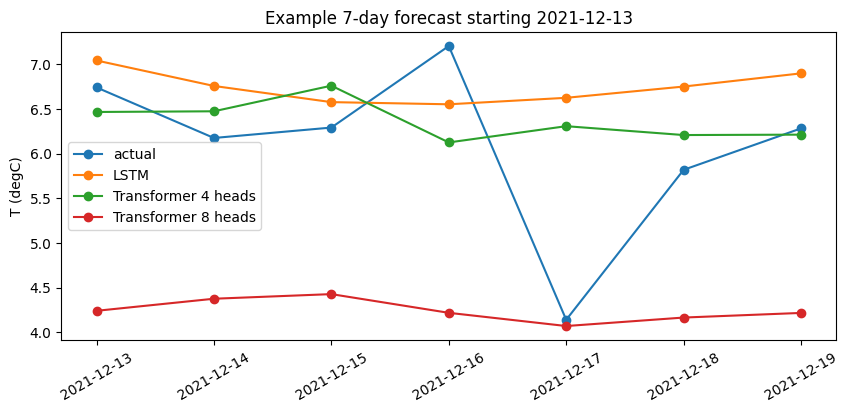

In [11]:
transformer_names = [name for name in predictions_c if name.startswith("Transformer")]

example_idx = 8
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(forecast_dates_test[example_idx], y_test_c[example_idx], marker="o", label="actual")
ax.plot(forecast_dates_test[example_idx], predictions_c["LSTM"][example_idx], marker="o", label="LSTM")
for name in transformer_names:
    ax.plot(forecast_dates_test[example_idx], predictions_c[name][example_idx], marker="o", label=name)
ax.set_title(f"Example 7-day forecast starting {pd.Timestamp(forecast_dates_test[example_idx, 0]).date()}")
ax.set_ylabel(TARGET)
ax.legend()
plt.xticks(rotation=30)
plt.show()

## F.
Evaluation – Computational Performance: Record the training time or epochs needed for each
model to converge. Also, note the number of parameters in each model. This information will feed into a
comparison of training efficiency and model complexity

In [12]:
performance_summary = training_summary.merge(accuracy_summary, on="model").sort_values("MAE (degC)")
performance_summary

,model,parameters,epochs_run,best_val_MSE_scaled,training_time_s,MAE (degC),RMSE (degC)
0,Transformer 8 heads,172225,19,0.370445,3.378920,3.986046,4.805913
1,Transformer 4 heads,172225,20,0.565279,2.808344,4.549549,5.911503
2,LSTM,75073,23,0.621609,1.175820,4.739524,6.136115


## G. 
Hyperparameter Tuning: Experiment with at least one or two hyperparameters on the Transformer.
For instance, try changing the number of attention heads (e.g., 4 vs 8 heads) or the depth (number of
Transformer layers). Observe the effect on validation performance and training time. You might also try
different sequence lengths for input or different forecast horizon lengths to see how the transformer handles
them versus the LSTM.

In [13]:
transformer_tuning = performance_summary[performance_summary["model"].str.contains("Transformer")].copy()
transformer_tuning[["model", "parameters", "epochs_run", "best_val_MSE_scaled", "training_time_s", "MAE (degC)", "RMSE (degC)"]]

,model,parameters,epochs_run,best_val_MSE_scaled,training_time_s,MAE (degC),RMSE (degC)
0,Transformer 8 heads,172225,19,0.370445,3.378920,3.986046,4.805913
1,Transformer 4 heads,172225,20,0.565279,2.808344,4.549549,5.911503


## H. 
Attention Visualization: For one example in the test set, visualize the Transformer’s attention weights.
For instance, pick a specific forecast date and plot the attention scores of the Transformer decoder for that
prediction with respect to the input timeline (and/or previous outputs). This could be done by extracting
the attention matrix from the model (in PyTorch’s nn.Transformer, you can register hooks or use the
attn output weights if using MultiheadAttention modules). The goal is to interpret which past time steps
the model found relevant for predicting a particular future step. Include a brief analysis of this: do the
attention weights align with intuitive patterns (e.g., focusing on daily patterns or recent trends)?

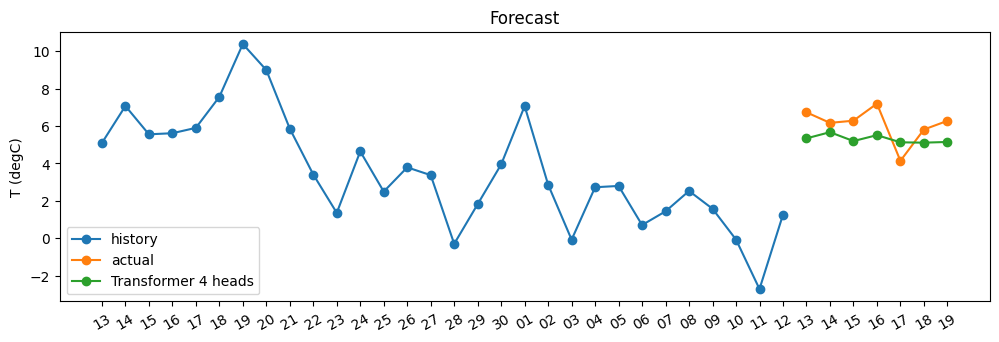

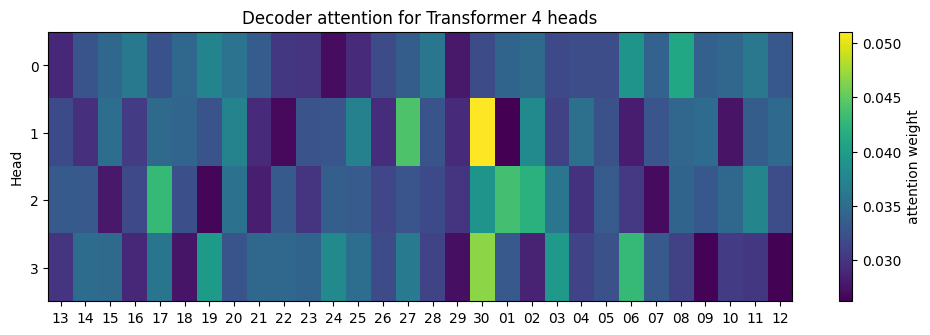

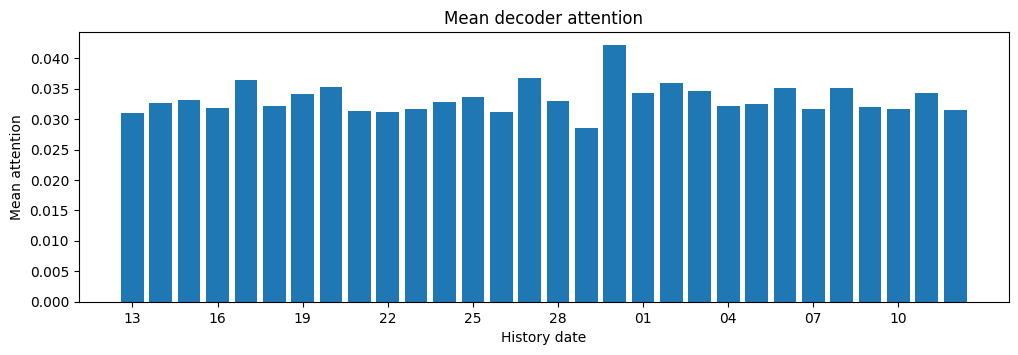

In [110]:
attention_model_name = transformer_names[0]
attention_model = experiments[attention_model_name]
attention_model.eval()
sample_x = torch.tensor(X_test[example_idx : example_idx + 1], device=DEVICE)

history_temp = target_scaler.inverse_transform(
    X_test[example_idx, :, target_index].reshape(-1, 1)
).ravel()
actual_temp = y_test_c[example_idx]
predicted_temp = predictions_c[attention_model_name][example_idx]

plt.figure(figsize=(12, 3.5))
plt.plot(history_dates_test[example_idx], history_temp, marker="o", label="history")
plt.plot(forecast_dates_test[example_idx], actual_temp, marker="o", label="actual")
plt.plot(forecast_dates_test[example_idx], predicted_temp, marker="o", label=attention_model_name)
all_plot_dates = np.concatenate([history_dates_test[example_idx], forecast_dates_test[example_idx]])
plt.title("Forecast")
plt.ylabel(TARGET)
plt.xticks(all_plot_dates, [pd.Timestamp(d).strftime("%d") for d in all_plot_dates], rotation=30)
plt.legend()
plt.show()


captured = {}
last_decoder_layer = attention_model.transformer.decoder.layers[-1]


def save_cross_attention_inputs(module, inputs):
    captured["query"] = inputs[0].detach()
    captured["key"] = inputs[1].detach()
    captured["value"] = inputs[2].detach()


hook = last_decoder_layer.multihead_attn.register_forward_pre_hook(save_cross_attention_inputs)
with torch.no_grad():
    _ = attention_model(sample_x)
hook.remove()

with torch.no_grad():
    _, attn_weights = last_decoder_layer.multihead_attn(
        captured["query"],
        captured["key"],
        captured["value"],
        need_weights=True,
        average_attn_weights=False,
    )

attention = attn_weights[0].cpu().numpy()  # heads x decoder_positions x encoder_positions
query_position = HORIZON - 1
valid_attention = attention[:, query_position, :]
mean_attention = valid_attention.mean(axis=0)

history_labels = [pd.Timestamp(d).strftime("%d") for d in history_dates_test[example_idx]]

plt.figure(figsize=(12, 3.5))
image = plt.imshow(valid_attention, aspect="auto", cmap="viridis")
plt.title(f"Decoder attention for {attention_model_name}")
plt.ylabel("Head")
plt.yticks(range(valid_attention.shape[0]))
plt.xticks(range(LOOKBACK), history_labels)
plt.colorbar(image, label="attention weight")
plt.show()

plt.figure(figsize=(12, 3.5))
plt.bar(range(LOOKBACK), mean_attention, color="tab:blue")
plt.title("Mean decoder attention")
plt.ylabel("Mean attention")
plt.xlabel("History date")
plt.xticks(range(0, LOOKBACK, 3), history_labels[::3])
plt.show()